# Tile generation with a SAT solver

This notebook documents how we resolved open problem #1 from `open_problems.ipynb`:

> *"When using the existing Gurobi algorithm, it takes quite a while to find all Tiles of level 5. It takes a much longer time to find those of level 6 (over two days running locally), and it is probably impossible to find those of level 7. This is probably not because the task is too difficult, but because the algorithm is not designed sufficiently cleverly. This needs attention."*

It received attention. By (1) reducing the problem to one boolean per *free symmetry orbit*, (2) encoding the still-life rules as plain CNF clauses for an open-source SAT solver, and (3) partitioning the search space into independent *cubes*, the complete level-6 database — **332,321 tiles** — is now enumerated exhaustively in **about two seconds** on a laptop, without a Gurobi licence. The result is validated by a five-tier ladder of independent checks, generalises to any Life-like cellular automaton, and the previously hand-made "dead edge" tiling constraints are now *derived* from the mosaic geometry — which unlocks level 7.

Everything below runs live; the heavy lifting is in `gol_mosaics.tile_domain` (geometry, symmetry orbits, dead-edge derivation) and `gol_mosaics.sat_search` (CNF construction, enumeration). The command-line pipeline with parallelism and checkpointing lives in `workstation/level6_search/search.py`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Import gol_mosaics (installed with: pip install -e .); fall back to ../src
# so the notebook also runs from a plain checkout.
try:
    import gol_mosaics
except ImportError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))

from gol_mosaics import MosaicGenerator, PatternLibrary
from gol_mosaics.life import is_still_life, life_step
from gol_mosaics import tile_domain, sat_search

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 100,
    "savefig.dpi": 1200,
})

## Step 1: The problem, and why the ILP saturates

A **Tile** of level $L$ is an $n \times n$ binary grid with $n = 6L$ that satisfies four families of constraints:

1. **Still life** (toroidal neighbourhoods): every live cell has 2 or 3 live neighbours (it survives), and no dead cell has exactly 3 (nothing is born).
2. **8-fold symmetry**: invariance under the full dihedral group $D_4$ (horizontal, vertical, both diagonals).
3. **Forced geometry**: the pond ring along the tile's diamond edge is forced alive; everything outside the diamond is forced dead.
4. **Dead edges**: a handful of near-edge cells are forced dead so that adjacent tiles in a mosaic cannot interact (Step 10 derives these from first principles).

The original approach (after Bosch's *Opt Art*) is an integer linear programme with three binaries per cell ($3n^2 = 3888$ variables at level 6) that finds one optimum, adds a *no-good cut* excluding it, and re-solves — so iteration $k$ carries $k$ extra constraints. Two structural problems compound: the model is ~66× larger than necessary (symmetry is imposed via equality constraints rather than exploited), and the enumeration is quadratic in the number of solutions. At level 6 that meant days; at level 7, hopeless.

In [2]:
counts_known = {1: 1, 2: 2, 3: 7, 4: 85, 5: 2632}
print(f"{'level':>5} {'grid':>8} {'ILP vars':>9} {'free orbits':>12} {'known tiles':>12}")
for L in range(1, 8):
    d = tile_domain.build_domain(L)
    known = counts_known.get(L, "?")
    print(f"{L:>5} {f'{d.n}x{d.n}':>8} {3 * d.n**2:>9} {len(d.free_reps):>12} {known!s:>12}")

level     grid  ILP vars  free orbits  known tiles
    1      6x6       108            1            1
    2    12x12       432            3            2
    3    18x18       972           10            7
    4    24x24      1728           22           85
    5    30x30      2700           38         2632
    6    36x36      3888           59            ?
    7    42x42      5292           84            ?


## Step 2: Symmetry-orbit reduction

The $D_4$ symmetry means a tile is fully determined by one value per **orbit** — the set of up to 8 cells mapped onto each other by the symmetries. Moreover, when *any* cell of an orbit is forced (alive on the pond edge, dead outside the diamond or on a dead edge), the ILP's symmetry equalities force the *whole orbit*; those orbits become constants. What remains is remarkably small: **59 free orbits at level 6** (not the 67 free cells a naive fundamental-domain count suggests — 8 more orbits are killed by forcings whose representative lies elsewhere) and 84 at level 7.

The search space is thus $2^{59}$ raw assignments, but the constraints prune it to a few hundred thousand solutions — exactly the regime SAT solvers dominate.

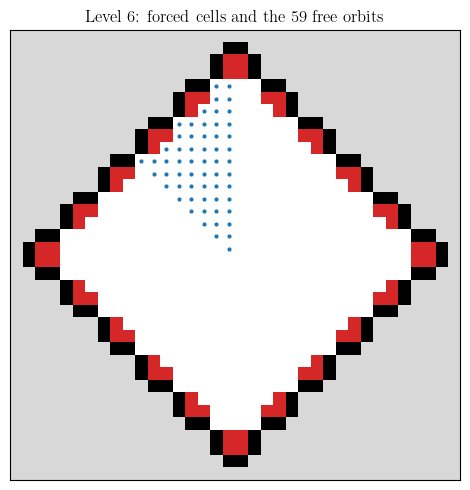

free cells: 440, free orbits (blue dots = representatives): 59


In [3]:
level = 6
d = tile_domain.build_domain(level)
edge_alive, outside_dead, dead_edges = tile_domain.forced_masks(level)

classes = np.zeros((d.n, d.n))          # free
classes[outside_dead == 1] = 1          # outside the diamond
classes[edge_alive == 1] = 2            # forced-alive pond edge
for (i, j) in dead_edges:
    classes[i, j] = 3                   # forced-dead interlock cells

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(classes, cmap=plt.matplotlib.colors.ListedColormap(
    ["white", "0.85", "black", "tab:red"]), interpolation="nearest")
free_cells = np.argwhere((classes == 0))
ax.set_title(f"Level {level}: forced cells and the {len(d.free_reps)} free orbits")
ax.set_xticks([]); ax.set_yticks([])
for (i, j) in d.free_reps:
    ax.plot(j, i, ".", color="tab:blue", markersize=4)
plt.tight_layout()
plt.show()
print(f"free cells: {int((classes == 0).sum())}, free orbits (blue dots = representatives): {len(d.free_reps)}")

## Step 3: The SAT encoding

One boolean variable per free orbit; forced orbits are folded in as constants. For each of the $n^2$ cells we look at its 8 neighbour *positions* (each position resolves to an orbit variable or a constant) and forbid every illegal exact neighbour count $c$ with binomial clauses — one clause per $c$-subset of the positions:

| cell state | forbidden counts (Conway) | clauses per count $c$ |
|---|---|---|
| alive | $c \notin \{2,3\}$ | $\binom{8}{c}$ |
| dead | $c \in \{3\}$ (birth) | $\binom{8}{3} = 56$ |

Two design points matter for exactness. First, positions are a **multiset**: near a symmetry axis several positions map to the same variable, and the clause simplifier (constant folding, duplicate collapse, tautology elimination) reproduces the ILP's positional counting. Second, there are **no auxiliary variables**, so later a blocking clause over the decision variables removes *exactly one* assignment — enumeration cannot repeat or skip solutions. After global deduplication (symmetric cells emit identical clauses) the formulas are tiny, and each carries a SHA-256 fingerprint so any change to the encoding is detectable.

The encoding is parametric in the rule: `build_cnf(level, birth=(3,), survival=(2,3))` — Step 9 uses this for other Life-like automata.

In [4]:
for L in (3, 4, 5, 6):
    t0 = time.time()
    enc = sat_search.build_cnf(L)
    print(f"level {L}: {enc.n_vars:>2} variables, {len(enc.clauses):>5} clauses, "
          f"built in {time.time() - t0:.2f}s, fingerprint {enc.sha256[:12]}...")

level 3: 10 variables,   254 clauses, built in 0.04s, fingerprint d4a1e8010292...
level 4: 22 variables,  1340 clauses, built in 0.08s, fingerprint 83120d119db9...


level 5: 38 variables,  3578 clauses, built in 0.14s, fingerprint afe3924af905...


level 6: 59 variables,  6716 clauses, built in 0.23s, fingerprint 926a451cb580...


## Step 4: Exhaustive enumeration, validated byte-exactly against levels 3–5

The AllSAT loop — solve, record, block, repeat until UNSAT — enumerates every solution. We validate the whole machine by re-deriving the shipped databases: the solution *sets* must match byte-for-byte.

In [5]:
for L in (3, 4, 5):
    t0 = time.time()
    found = sat_search.enumerate_tiles(L)
    elapsed = time.time() - t0
    shipped = PatternLibrary.load(L).solutions.astype(np.uint8)
    exact = {g.tobytes() for g in found} == {g.tobytes() for g in shipped}
    mark = "✓" if exact else "✗"
    print(f"level {L}: {len(found):>4} tiles in {elapsed:5.2f}s — "
          f"byte-exact match with shipped database: {mark}")
    assert exact

level 3:    7 tiles in  0.05s — byte-exact match with shipped database: ✓
level 4:   85 tiles in  0.08s — byte-exact match with shipped database: ✓


level 5: 2632 tiles in  0.18s — byte-exact match with shipped database: ✓


## Step 5: Cube-and-conquer parallelism

For large levels we fix the first $k$ decision variables to each of the $2^k$ bit patterns ("cubes"). The cubes **partition** the assignment space — no overlap, no gap — so the union of the per-cube enumerations is complete and duplicate-free *by construction*, each cube is an independent job for a CPU core, and no single solver ever accumulates the full set of blocking clauses (which is what made the ILP loop quadratic).

The production pipeline (`workstation/level6_search/search.py`) adds checkpointing (one atomically-written file per finished cube; interrupted runs resume where they stopped) and a mandatory validation gate. Measured on a 10-core laptop: **level 6, 1024 cubes, all 332,321 solutions in 2.1 s** of solving. Below, the partition argument in miniature.

In [6]:
enc5 = sat_search.build_cnf(5)
per_cube, all_rows = [], []
t0 = time.time()
for cube in range(16):
    bits = sat_search.enumerate_all(enc5, extra_units=sat_search.cube_units(cube, 4))
    per_cube.append(len(bits))
    all_rows.append(bits)
bits = np.vstack(all_rows)
unique = len(np.unique(bits, axis=0))
print(f"level 5 split into 16 cubes: per-cube counts {per_cube}")
print(f"total {bits.shape[0]} = unique {unique} = expected 2632 "
      f"({time.time() - t0:.2f}s) ✓")
assert bits.shape[0] == unique == 2632

level 5 split into 16 cubes: per-cube counts [1158, 0, 0, 0, 0, 0, 257, 0, 0, 0, 0, 0, 1217, 0, 0, 0]
total 2632 = unique 2632 = expected 2632 (0.06s) ✓


## Step 6: The validation ladder

Byte-exact re-derivation of levels 3–5 is necessary but not sufficient — an encoding bug could in principle affect only level 6. We therefore stack independent checks:

1. **Byte-exact levels 3–5** (Step 4) — against databases produced by a *different algorithm* (Gurobi ILP) years earlier.
2. **SAT-free brute force**: enumerate *all* $2^{n_{\text{free}}}$ orbit assignments with vectorised numpy and keep the valid ones. No solver, no clauses — just the rules. Feasible through level 4.
3. **Cross-solver determinism**: CaDiCaL and Glucose are unrelated codebases; both must produce the identical set.
4. **Independent per-tile verifier**: every solution of every production run is re-checked by `workstation/level6_search/verify.py`, which shares no code with the encoding.
5. **Whole-mosaic stability** (the strongest): tiles are only useful if *assembled mosaics* are global still lifes. We build real mosaics through the production pipeline and step them with an independent Game of Life implementation. This is also the first-ever validation of the level-6 dead edges, which the ILP era never exercised.

In [7]:
# Tier 2: SAT-free exhaustive brute force (levels 3 and 4)
for L in (3, 4):
    t0 = time.time()
    brute = sat_search.bruteforce_tiles(L)
    sat = sat_search.enumerate_tiles(L)
    exact = sat.tobytes() == brute.astype(np.uint8).tobytes()
    mark = "✓" if exact else "✗"
    k = len(tile_domain.build_domain(L).free_reps)
    print(f"level {L}: all 2^{k} = {2**k:,} assignments checked in "
          f"{time.time() - t0:5.1f}s -> {len(brute)} tiles; SAT set identical: {mark}")
    assert exact

level 3: all 2^10 = 1,024 assignments checked in   0.0s -> 7 tiles; SAT set identical: ✓


level 4: all 2^22 = 4,194,304 assignments checked in  51.8s -> 85 tiles; SAT set identical: ✓


In [8]:
# Tier 3: cross-solver determinism on level 5
a = sat_search.enumerate_tiles(5, solver_name="cadical195")
b = sat_search.enumerate_tiles(5, solver_name="glucose42")
exact = a.tobytes() == b.tobytes()
print(f"CaDiCaL 1.9.5 vs Glucose 4.2: identical sorted output: "
      f"{'✓' if exact else '✗'}")
assert exact

CaDiCaL 1.9.5 vs Glucose 4.2: identical sorted output: ✓


In [9]:
# Tier 5: whole-mosaic stability, levels 3-6 (including the 332,321-tile level 6)
def random_mosaic(level, grid=10, seed=0, library=None):
    rng = np.random.default_rng(seed)
    generator = MosaicGenerator(level=level, grid_size=grid)
    if library is not None:
        generator._pattern_library = library
    lowres_first = rng.integers(0, 256, (grid // 2 + 1, grid // 2)).astype(float)
    lowres_second = rng.integers(0, 256, (grid // 2, grid // 2 + 1)).astype(float)
    return generator._build_mosaic(lowres_first, lowres_second,
                                   empty_tiles_cutoff=1.0)

for L in (3, 4, 5, 6):
    stable = all(is_still_life(random_mosaic(L, seed=s)) for s in (0, 1, 2))
    print(f"level {L}: 3 random mosaics are global still lifes: "
          f"{'✓' if stable else '✗'}")
    assert stable

level 3: 3 random mosaics are global still lifes: ✓
level 4: 3 random mosaics are global still lifes: ✓
level 5: 3 random mosaics are global still lifes: ✓


level 6: 3 random mosaics are global still lifes: ✓


In [10]:
# ...and the check has teeth: tiles enumerated WITHOUT the dead-edge
# constraints are perfectly valid still lifes in isolation, but a mosaic
# containing them falls apart. (Exhaustive follow-up: every one of the 267
# violators breaks a mosaic, even repeated uniformly and even in contact
# with only the bare pond frame - the dead edges are unconditionally
# necessary for composition.)
L = 4
unconstrained = sat_search.enumerate_tiles(L, dead_edges=[])
cells = sorted(tile_domain.derive_dead_edges_full(L))
ii, jj = zip(*cells)
violators = unconstrained[unconstrained[:, list(ii), list(jj)].any(axis=1)]
n = violators.shape[1]
assert all(is_still_life(np.pad(t, n)) for t in violators[:20])

library = PatternLibrary(level=L)
library._solutions = violators
mosaic = random_mosaic(L, seed=0, library=library)
mosaic = np.clip(mosaic, 0, 1)
unstable = int((life_step(mosaic) != mosaic).sum())
print(f"without dead edges: {len(unconstrained)} tiles instead of 85, "
      f"of which {len(violators)} violate the dead-edge cells;")
print(f"a mosaic mixing them changes in {unstable} cells after one step "
      f"{'✓ (detected)' if unstable else '✗'}")
assert unstable > 0

without dead edges: 352 tiles instead of 85, of which 267 violate the dead-edge cells;
a mosaic mixing them changes in 536 cells after one step ✓ (detected)


## Step 7: Level 6 — the new database

The complete level-6 database ships with the package as **2.7 MB** of packed orbit bits (59 bits per tile instead of a $36\times36$ grid — 162× smaller) and is expanded transparently by `PatternLibrary.load(6)`. The tiles span a wider density range than level 5, which translates into finer greyscale rendition in mosaics.

level 6: 332,321 tiles, loaded and expanded from packed bits in 0.00s


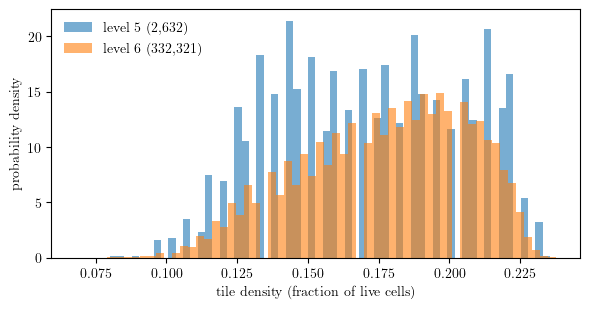

In [11]:
t0 = time.time()
lib6 = PatternLibrary.load(6)
lib5 = PatternLibrary.load(5)
print(f"level 6: {len(lib6.solutions):,} tiles, loaded and expanded from "
      f"packed bits in {time.time() - t0:.2f}s")

dens5 = lib5.solutions.mean(axis=(1, 2))
dens6 = lib6.solutions.mean(axis=(1, 2))
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(dens5, bins=60, density=True, alpha=0.6, label=f"level 5 ({len(dens5):,})")
ax.hist(dens6, bins=60, density=True, alpha=0.6, label=f"level 6 ({len(dens6):,})")
ax.set_xlabel("tile density (fraction of live cells)")
ax.set_ylabel("probability density")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

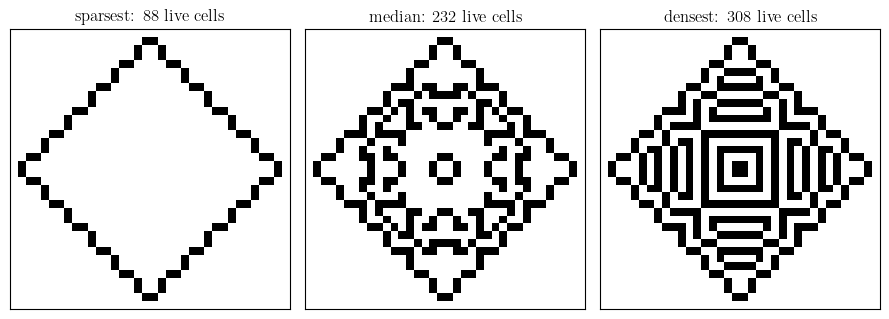

In [12]:
counts6 = lib6.solutions.sum(axis=(1, 2))
picks = [int(np.argmin(counts6)), int(np.argsort(counts6)[len(counts6) // 2]),
         int(np.argmax(counts6))]
labels = ["sparsest", "median", "densest"]
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, idx, lab in zip(axes, picks, labels):
    ax.imshow(lib6.solutions[idx], cmap="binary", interpolation="nearest")
    ax.set_title(f"{lab}: {int(counts6[idx])} live cells")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

level-6 mosaic: 1548x1548 cells, 134,984 alive; global still life: ✓


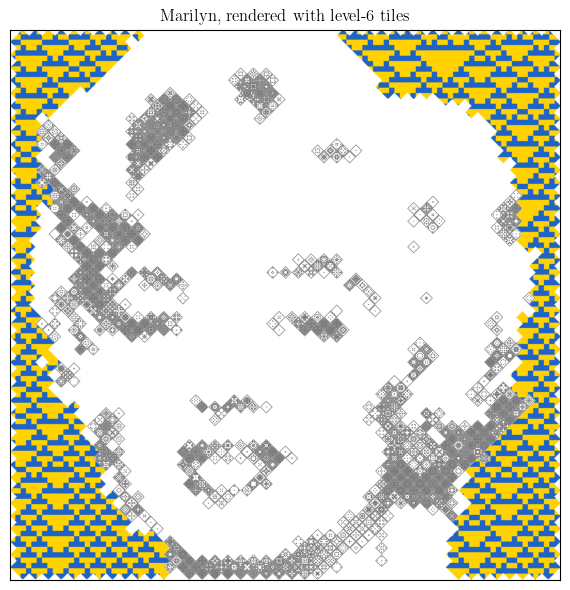

In [13]:
# The full production pipeline at level 6, end to end.
from PIL import Image

img = Image.open("../input/images/marilyn.png")
generator = MosaicGenerator(level=6, grid_size=60)
image, gol, mask = generator.generate_from_pil(
    img, remove_background=False, seed=0, return_arrays=True)

stable = is_still_life(gol)
print(f"level-6 mosaic: {gol.shape[1]}x{gol.shape[0]} cells, "
      f"{int(gol.sum()):,} alive; global still life: "
      f"{'✓' if stable else '✗'}")
assert stable

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Marilyn, rendered with level-6 tiles")
plt.tight_layout()
plt.show()

## Step 8: How fast do the tile counts grow?

The counts 1, 2, 7, 85, 2632, 332321 grow super-exponentially: the ratio between consecutive levels is itself growing (2, 3.5, 12.1, 31.0, 126.3). The number of free orbits grows quadratically with the level ($\sim n^2/8$), so $\log(\text{count})$ is well described by a quadratic in $L$ — which is what we fit to extrapolate level 7.

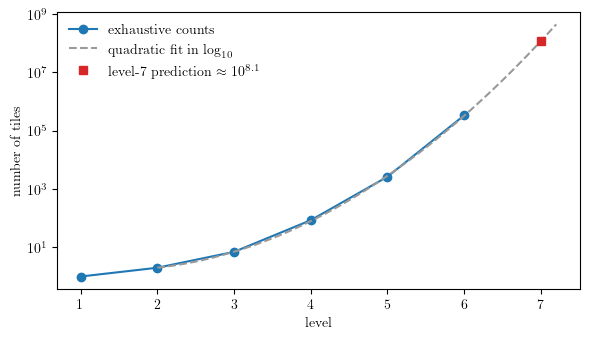

predicted level-7 count: ~1.17e+08 tiles
as raw 42x42 grids that would be ~207 GB; as packed orbit bits ~1.3 GB


In [14]:
levels = np.arange(1, 7)
counts = np.array([1, 2, 7, 85, 2632, 332321], dtype=float)
fit = np.polyfit(levels[1:], np.log10(counts[1:]), 2)
pred7 = 10 ** np.polyval(fit, 7)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(levels, counts, "o-", label="exhaustive counts")
xs = np.linspace(2, 7.2, 100)
ax.semilogy(xs, 10 ** np.polyval(fit, xs), "--", color="0.6",
            label="quadratic fit in $\\log_{10}$")
ax.semilogy([7], [pred7], "s", color="tab:red",
            label=f"level-7 prediction $\\approx 10^{{{np.log10(pred7):.1f}}}$")
ax.set_xlabel("level"); ax.set_ylabel("number of tiles")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
print(f"predicted level-7 count: ~{pred7:.2e} tiles")
print(f"as raw 42x42 grids that would be ~{pred7 * 42 * 42 / 1e9:,.0f} GB; "
      f"as packed orbit bits ~{pred7 * 11 / 1e9:.1f} GB")

## Step 9: Beyond Conway — any Life-like cellular automaton

Nothing in the pipeline is specific to B3/S23. A Life-like rule B$b$/S$s$ only changes *which* neighbour counts are forbidden: a live cell must have $c \in s$, a dead cell must have $c \notin b$. The clause generator takes the rule as a parameter, and the whole validation machinery (brute force, mosaic stability) is rule-parametric too.

**HighLife** (B36/S23) is a clean demonstration: it shares Conway's survival set and adds one birth condition, so every HighLife tile is a Conway tile whose dead cells never see exactly 6 live neighbours — the HighLife tile sets must be *subsets* of Conway's. The SAT enumeration and the post-hoc filter must agree exactly.

One caveat for exotic rules: the forced pond edge itself must be a still life in the target rule (true for HighLife), and tiles only interlock if the pond-contact joints stay stable — the whole-mosaic check verifies that empirically per rule.

In [15]:
for L in (3, 4, 5):
    highlife = sat_search.enumerate_tiles(L, *sat_search.HIGHLIFE)
    conway = PatternLibrary.load(L).solutions.astype(np.uint8)
    subset = conway[~sat_search.rule_violations(conway, *sat_search.HIGHLIFE)]
    exact = {g.tobytes() for g in highlife} == {g.tobytes() for g in subset}
    print(f"level {L}: {len(highlife):>4} HighLife tiles of {len(conway):>4} Conway "
          f"tiles; SAT == post-filtered subset: {'✓' if exact else '✗'}")
    assert exact

level 3:    6 HighLife tiles of    7 Conway tiles; SAT == post-filtered subset: ✓
level 4:   65 HighLife tiles of   85 Conway tiles; SAT == post-filtered subset: ✓


level 5: 1519 HighLife tiles of 2632 Conway tiles; SAT == post-filtered subset: ✓


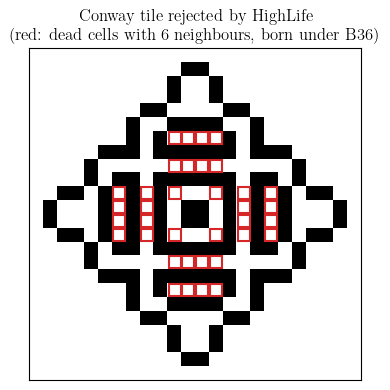

In [16]:
# A Conway tile that HighLife rejects: some dead cell sees exactly 6
# live neighbours, so in HighLife a cell would be BORN there.
L = 4
conway = PatternLibrary.load(L).solutions.astype(np.uint8)
bad = conway[sat_search.rule_violations(conway, *sat_search.HIGHLIFE)]
tile = bad[0]
counts = np.zeros(tile.shape, dtype=int)
for di in (-1, 0, 1):
    for dj in (-1, 0, 1):
        if di or dj:
            counts += np.roll(np.roll(tile.astype(int), di, 0), dj, 1)
births = (tile == 0) & (counts == 6)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(tile, cmap="binary", interpolation="nearest")
for (i, j) in np.argwhere(births):
    ax.plot(j, i, "s", markerfacecolor="none", markeredgecolor="tab:red",
            markersize=9, markeredgewidth=1.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Conway tile rejected by HighLife\n(red: dead cells with 6 neighbours, born under B36)")
plt.tight_layout()
plt.show()

## Step 10: Level 7 unlocked — dead edges from first principles

The dead-edge lists were historically hand-made, and stopped at level 6. They can be *derived*. In a mosaic, the neighbouring tiles of a tile sit at twelve offsets: $(\pm n/2, \pm n/2)$ for the interlocking diagonal grid (the pad size works out to exactly $n/2$) and $(0,\pm n)$, $(\pm n, 0)$, $(\pm n, \pm n)$ for its own grid. Let $A$ be the tile's possibly-alive diamond and $B$ the union of its neighbours' diamonds. Then

$$\text{shared} = \operatorname{dil}_1(A) \cap \operatorname{dil}_1(B), \qquad \text{dead} = \text{free}(A) \cap \operatorname{dil}_1(\text{shared}),$$

with $\operatorname{dil}_1$ the Chebyshev-1 dilation: a *shared* cell is one whose fate depends on two tiles, and every free cell that could influence a shared cell must be forced dead — after which all shared cells see only forced cells, whose contact configuration is stable by construction. This reproduces the five historical lists **exactly** (orbit-closed; $12L - 8$ cells per level) and extends to any level. `PatternLibrary._get_dead_edges` now delegates to this derivation.

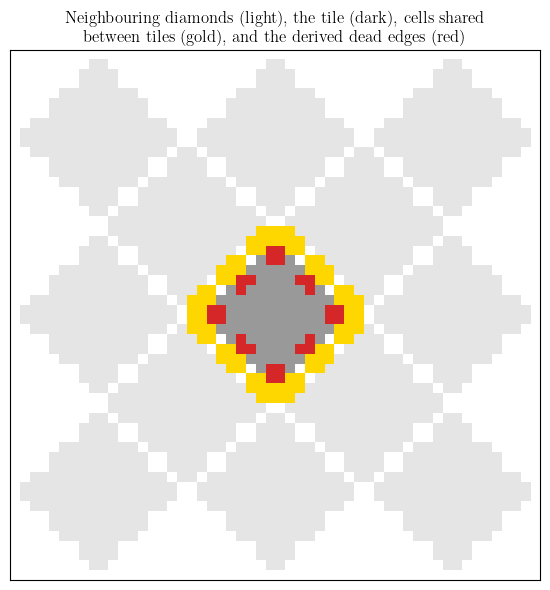

level 2: derivation == historical list (orbit-closed): ✓
level 3: derivation == historical list (orbit-closed): ✓
level 4: derivation == historical list (orbit-closed): ✓
level 5: derivation == historical list (orbit-closed): ✓
level 6: derivation == historical list (orbit-closed): ✓

derived level-7 dead edges: [(2, 21), (3, 21), (5, 23), (5, 24), (6, 24), (8, 26), (8, 27), (9, 27), (11, 29), (11, 30)]


In [17]:
from scipy.ndimage import binary_dilation, binary_fill_holes

# The derivation, visualised at level 3.
L = 3
n = 6 * L
edge_alive, _ = tile_domain._base_masks(L)
diamond = binary_fill_holes(edge_alive)
canvas = np.zeros((3 * n, 3 * n), dtype=bool)
canvas[n:2 * n, n:2 * n] = diamond
offsets = ([(si * n // 2, sj * n // 2) for si in (-1, 1) for sj in (-1, 1)]
           + [(0, n), (0, -n), (n, 0), (-n, 0)]
           + [(si * n, sj * n) for si in (-1, 1) for sj in (-1, 1)])
others = np.zeros_like(canvas)
for di, dj in offsets:
    others[n + di:2 * n + di, n + dj:2 * n + dj] |= diamond
d1 = np.ones((3, 3), bool)
shared = binary_dilation(canvas, d1) & binary_dilation(others, d1)
free = canvas.copy(); free[n:2 * n, n:2 * n] &= edge_alive == 0
dead = free & binary_dilation(shared, d1)

img = np.zeros(canvas.shape)
img[others] = 1; img[canvas] = 2; img[shared] = 3; img[dead] = 4
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap=plt.matplotlib.colors.ListedColormap(
    ["white", "0.9", "0.6", "gold", "tab:red"]), interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Neighbouring diamonds (light), the tile (dark), cells shared\n"
             "between tiles (gold), and the derived dead edges (red)")
plt.tight_layout()
plt.show()

historical = {2: [(2, 6), (3, 6)], 3: [(2, 9), (3, 9), (5, 11), (5, 12)],
              4: [(2, 11), (3, 11), (5, 14), (5, 15), (6, 15)],
              5: [(2, 15), (3, 15), (5, 17), (5, 18), (6, 18), (8, 20), (8, 21)],
              6: [(2, 18), (3, 18), (5, 20), (5, 21), (6, 21), (8, 23), (8, 24), (9, 24)]}
for lvl, lits in historical.items():
    closure = {img_ for c in lits
               for img_ in tile_domain.symmetric_coords(*c, 6 * lvl)}
    ok = tile_domain.derive_dead_edges_full(lvl) == closure
    print(f"level {lvl}: derivation == historical list (orbit-closed): "
          f"{'✓' if ok else '✗'}")
    assert ok
print(f"\nderived level-7 dead edges: {tile_domain.derive_dead_edges(7)}")

level 7: 84 free orbits, 11,006 clauses
first 5,000 level-7 tiles in 0.2s (40,520 tiles/s single-core); all rule-valid: ✓


3 random mosaics from real level-7 tiles are global still lifes: ✓


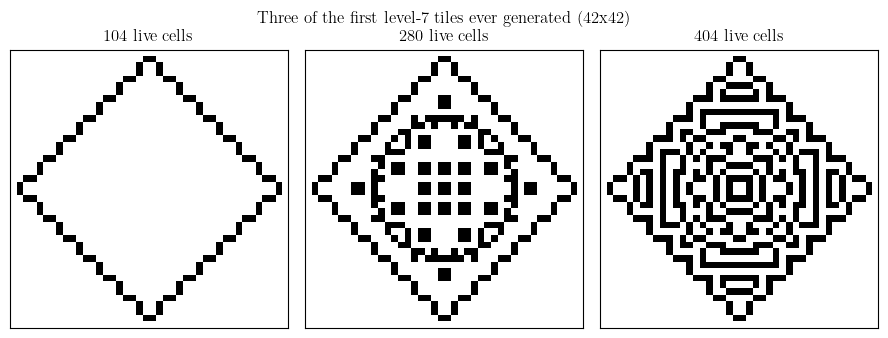

In [18]:
# A bounded level-7 probe: the machinery simply works at level 7.
enc7 = sat_search.build_cnf(7)
print(f"level 7: {enc7.n_vars} free orbits, {len(enc7.clauses):,} clauses")

t0 = time.time()
bits = sat_search.enumerate_all(enc7, limit=5000)
rate = len(bits) / (time.time() - t0)
tiles7 = enc7.domain.expand_many(bits)
valid = ~sat_search.rule_violations(tiles7)
print(f"first {len(bits):,} level-7 tiles in {time.time() - t0:.1f}s "
      f"({rate:,.0f} tiles/s single-core); all rule-valid: "
      f"{'✓' if valid.all() else '✗'}")
assert valid.all()

# And level-7 mosaics assembled from them are global still lifes.
lib7 = PatternLibrary(level=7)
lib7._solutions = tiles7
stable = all(is_still_life(random_mosaic(7, seed=s, library=lib7))
             for s in (0, 1, 2))
print(f"3 random mosaics from real level-7 tiles are global still lifes: "
      f"{'✓' if stable else '✗'}")
assert stable

fig, axes = plt.subplots(1, 3, figsize=(9, 3.4))
counts7 = tiles7.sum(axis=(1, 2))
for ax, idx in zip(axes, [int(np.argmin(counts7)), len(tiles7) // 2,
                          int(np.argmax(counts7))]):
    ax.imshow(tiles7[idx], cmap="binary", interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{int(counts7[idx])} live cells")
fig.suptitle("Three of the first level-7 tiles ever generated (42x42)")
plt.tight_layout()
plt.show()

## Step 11: Outlook

**The full level-7 run** is now an engineering exercise, not a research question. With $\sim 10^8$ expected tiles, the pipeline keeps everything as packed orbit bits (11 bytes per tile, a few GB total; raw grids would be hundreds of GB):

```bash
cd workstation/level6_search
python search.py validate                      # mandatory gate + calibration
python search.py run --level 7 --cube-bits 16  # checkpointed; resumes after interruption
# -> solutions_pattern_level_7_orbits.npy (packed; expand in chunks with
#    gol_mosaics.tile_domain.unpack_solutions)
```

Extrapolating the measured single-core rate to a multi-core workstation puts the enumeration at **hours, not days** — the storage and chunked verification, not the solving, are the real work.

**Loose ends we consider closed**: level 6 is exhaustively enumerated, five-way validated, and ships with the package (`PatternLibrary.load(6)`, and level 6 is available in the web app); the dead edges are derived rather than hand-made, with the historical lists reproduced exactly; the method generalises to any Life-like rule.

**Open directions**: whether the derived dead edges are *necessary* as well as sufficient (Step 6's teeth demo shows some of them are; a minimality study would sharpen the tiling theory); characterising the growth constant of the tile counts; and mosaics from non-Conway rules end to end (the tiles exist — Step 9 — but the ECA background and renderer default to Conway aesthetics).